In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

from core.cell import CellConfig
from core.perception import PerceptionConfig
from core.update import UpdateConfig
from core.grid import Grid3D, GridConfig

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

cell_cfg = CellConfig(hidden_channels=16, visible_channels=4)
perc_cfg = PerceptionConfig(kernel_radius=1, channel_groups=3)
upd_cfg = UpdateConfig(hidden_dim=64, stochastic_update=True, fire_rate=0.5)
grid_cfg = GridConfig(size=(32, 32, 32))

model = Grid3D(cell_cfg, perc_cfg, upd_cfg, grid_cfg).to(device)
print("Model initialized on", device)

state = model.seed_center(batch_size=1, device=device)
state += 1e-3 * torch.randn_like(state)

Model initialized on cuda


In [3]:
num_steps = 32
log = []

with torch.no_grad():
    for i in range(num_steps):
        state = model(state, steps=1)
        mean = state.mean().item()
        std = state.std().item()
        minv = state.min().item()
        maxv = state.max().item()
        log.append((i, mean, std, minv, maxv))
        print(f"Step {i:02d} | mean={mean:+.4f}, std={std:.4f}, min={minv:.4f}, max={maxv:.4f}")

Step 00 | mean=+0.0000, std=0.0021, min=-0.0051, max=1.0000
Step 01 | mean=+0.0000, std=0.0021, min=-0.0103, max=1.0000
Step 02 | mean=+0.0000, std=0.0025, min=-0.0206, max=1.0000
Step 03 | mean=+0.0000, std=0.0025, min=-0.0206, max=1.0000
Step 04 | mean=+0.0000, std=0.0025, min=-0.0412, max=1.0000
Step 05 | mean=+0.0000, std=0.0025, min=-0.0412, max=1.0000
Step 06 | mean=+0.0000, std=0.0025, min=-0.0824, max=1.0000
Step 07 | mean=+0.0000, std=0.0026, min=-0.1187, max=1.0000
Step 08 | mean=+0.0000, std=0.0027, min=-0.2373, max=1.0000
Step 09 | mean=+0.0000, std=0.0031, min=-0.4747, max=1.0000
Step 10 | mean=+0.0000, std=0.0041, min=-0.9493, max=1.0000
Step 11 | mean=+0.0000, std=0.0055, min=-1.0000, max=1.0000
Step 12 | mean=+0.0000, std=0.0062, min=-1.0000, max=1.0000
Step 13 | mean=+0.0000, std=0.0079, min=-1.0000, max=1.0000
Step 14 | mean=+0.0000, std=0.0103, min=-1.0000, max=1.0000
Step 15 | mean=+0.0000, std=0.0132, min=-1.0000, max=1.0000
Step 16 | mean=+0.0000, std=0.0154, min=

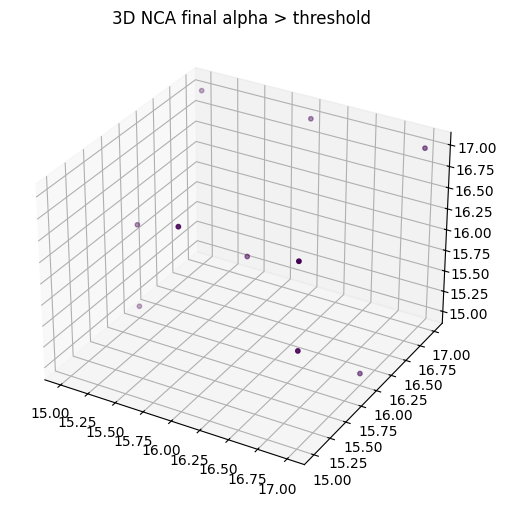

In [4]:
alpha = state[0, -1].cpu().numpy()
threshold = 0.1
xs, ys, zs = np.nonzero(alpha > threshold)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(xs, ys, zs, c=alpha[alpha > threshold], cmap="viridis", s=10)
ax.set_title("3D NCA final alpha > threshold")
plt.show()